In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
import os
import shutil

# Create working directory
os.makedirs('/content/data', exist_ok=True)

print("="*60)
print("📤 UPLOAD YOUR 'Disease Images' FOLDER")
print("="*60)
print("\n1. Click the 'Files' icon (📁) on the left sidebar")
print("2. Click 'Upload to session storage'")
print("3. Select your entire 'Disease Images' folder")
print("4. Wait for upload to complete")
print("\n⚠️ After uploading, run the next cell...")

📤 UPLOAD YOUR 'Disease Images' FOLDER

1. Click the 'Files' icon (📁) on the left sidebar
2. Click 'Upload to session storage'
3. Select your entire 'Disease Images' folder
4. Wait for upload to complete

⚠️ After uploading, run the next cell...


In [3]:
import os

# Your folder path in Google Drive
drive_folder = '/content/drive/MyDrive/Disease Images'

if os.path.exists(drive_folder):
    print("✅ 'Disease Images' folder found in Google Drive!")

    # List contents
    print("\n📁 Contents:")
    for item in os.listdir(drive_folder):
        if os.path.isdir(os.path.join(drive_folder, item)):
            print(f"   - {item}")
else:
    print("❌ 'Disease Images' folder not found in Google Drive.")
    print("\nPlease make sure the folder is at:")
    print("   /content/drive/MyDrive/Disease Images")
    print("\nIf it's in a different location, please move it to:")
    print("   My Drive/Disease Images")

✅ 'Disease Images' folder found in Google Drive!

📁 Contents:
   - Poultry Disease
   - Multi-crop diseases
   - Livestock Diseases


In [4]:
import os
import shutil

# Define paths
drive_source = '/content/drive/MyDrive/Disease Images'
colab_destination = '/content/data/disease_images'

if os.path.exists(drive_source):
    print("📁 Copying from Google Drive to Colab...")

    # Create destination folder
    os.makedirs(colab_destination, exist_ok=True)

    # Copy all subfolders
    for item in os.listdir(drive_source):
        src_path = os.path.join(drive_source, item)
        dst_path = os.path.join(colab_destination, item)

        if os.path.isdir(src_path):
            print(f"   Copying: {item}")
            if os.path.exists(dst_path):
                shutil.rmtree(dst_path)
            shutil.copytree(src_path, dst_path)

    print(f"\n✅ All data copied to: {colab_destination}")
else:
    print("❌ 'Disease Images' folder not found in Google Drive.")
    print("\nPlease upload it to:")
    print("   My Drive/Disease Images")

📁 Copying from Google Drive to Colab...
   Copying: Poultry Disease
   Copying: Multi-crop diseases
   Copying: Livestock Diseases

✅ All data copied to: /content/data/disease_images


In [5]:
import os

data_dir = '/content/data/disease_images'

print("="*60)
print("📁 VERIFYING YOUR FOLDER STRUCTURE")
print("="*60)

# Your actual folder names
domains = {
    'Poultry Disease': 'poultry',
    'Multi-crop diseases': 'crops',
    'Livestock Diseases': 'livestock'
}

total_images = 0

for folder_name, short_name in domains.items():
    folder_path = os.path.join(data_dir, folder_name)

    if os.path.exists(folder_path):
        print(f"\n✅ {folder_name}:")
        classes = [f for f in os.listdir(folder_path)
                  if os.path.isdir(os.path.join(folder_path, f))]

        for cls in classes:
            class_path = os.path.join(folder_path, cls)
            num_images = len([f for f in os.listdir(class_path)
                            if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            total_images += num_images
            print(f"   - {cls}: {num_images} images")
    else:
        print(f"\n❌ {folder_name}: Not found")

print(f"\n📊 Total images found: {total_images}")

📁 VERIFYING YOUR FOLDER STRUCTURE

✅ Poultry Disease:
   - salmonella: 2276 images
   - healthy: 2057 images
   - new castle disease: 376 images
   - coccidiosis: 2103 images

✅ Multi-crop diseases:
   - Rice Blast: 1440 images
   - thirps on  cotton: 36 images
   - red cotton bug: 69 images
   - Wheat black rust: 161 images
   - Tungro: 1308 images
   - Yellow Rust Sugarcane: 505 images
   - Sugarcane Healthy: 522 images
   - Mosaic sugarcane: 462 images
   - Brownspot: 1640 images
   - Wheat Brown leaf Rust: 90 images
   - maize fall armyworm: 107 images
   - maize ear rot: 115 images
   - cotton mealy bug: 92 images
   - Cotton Aphid: 39 images
   - pink bollworm in cotton: 28 images
   - Wheat powdery mildew: 169 images
   - cotton whitefly: 54 images
   - Healthy cotton: 425 images
   - RedRust sugarcane: 75 images
   - Wilt: 419 images
   - Healthy Maize: 1162 images
   - Healthy Wheat: 180 images
   - Flag Smut: 179 images
   - Wheat Stem fly: 172 images
   - Wheat mite: 154 ima

In [6]:
!pip install torch torchvision matplotlib tqdm scikit-learn pillow seaborn

import torch
print(f"\n✅ PyTorch version: {torch.__version__}")
print(f"✅ CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")


✅ PyTorch version: 2.11.0+cu128
✅ CUDA available: True
✅ GPU: Tesla T4


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
from tqdm import tqdm
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seed
torch.manual_seed(42)
np.random.seed(42)

Using device: cuda


In [8]:
class FastModelTrainer:
    """Optimized trainer with mixed precision and early stopping."""

    def __init__(self, folder_name, short_name, data_dir, num_epochs=5, batch_size=64, lr=0.001):
        self.folder_name = folder_name
        self.short_name = short_name
        self.data_dir = data_dir
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.lr = lr
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        self.domain_path = os.path.join(data_dir, folder_name)
        self.train_path = os.path.join(self.domain_path, 'train')
        self.val_path = os.path.join(self.domain_path, 'val')
        self.model_path = f'/content/drive/MyDrive/models/{short_name}_model.pth'

        self.class_names = []
        self.best_val_acc = 0.0

        print(f"\n{'='*60}")
        print(f"🏗️  Training {folder_name.upper()} Model")
        print(f"{'='*60}")
        print(f"Data path: {self.domain_path}")
        print(f"Save path: {self.model_path}")
        print(f"Epochs: {num_epochs}, Batch Size: {batch_size}")

    def prepare_data(self):
        """Split data into train/val folders."""
        print("\n📁 Preparing data...")

        if os.path.exists(self.train_path) and os.path.exists(self.val_path):
            print("✅ Train/val split already exists.")
            return

        class_folders = [f for f in os.listdir(self.domain_path)
                        if os.path.isdir(os.path.join(self.domain_path, f))
                        and f not in ['train', 'val']]

        if not class_folders:
            raise ValueError(f"No class folders found in {self.domain_path}")

        print(f"Found classes: {class_folders}")

        os.makedirs(self.train_path, exist_ok=True)
        os.makedirs(self.val_path, exist_ok=True)

        for class_name in class_folders:
            class_path = os.path.join(self.domain_path, class_name)
            images = [f for f in os.listdir(class_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'))]

            if not images:
                print(f"⚠️ No images in {class_name}")
                continue

            train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

            os.makedirs(os.path.join(self.train_path, class_name), exist_ok=True)
            os.makedirs(os.path.join(self.val_path, class_name), exist_ok=True)

            for img in train_imgs:
                shutil.copy(os.path.join(class_path, img),
                           os.path.join(self.train_path, class_name, img))
            for img in val_imgs:
                shutil.copy(os.path.join(class_path, img),
                           os.path.join(self.val_path, class_name, img))

            print(f"  {class_name}: {len(train_imgs)} train, {len(val_imgs)} val")

        self.class_names = class_folders
        print(f"✅ Data prepared. {len(self.class_names)} classes.")

    def get_transforms(self):
        """Get data transforms."""
        train_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(20),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

        val_transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])

        return train_transform, val_transform

    def load_data(self):
        """Load data loaders."""
        train_transform, val_transform = self.get_transforms()

        train_dataset = datasets.ImageFolder(self.train_path, transform=train_transform)
        val_dataset = datasets.ImageFolder(self.val_path, transform=val_transform)

        self.class_names = train_dataset.classes

        train_loader = DataLoader(train_dataset, batch_size=self.batch_size,
                                 shuffle=True, num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=self.batch_size,
                               shuffle=False, num_workers=2, pin_memory=True)

        print(f"\n📊 Data stats:")
        print(f"  Classes: {self.class_names}")
        print(f"  Train samples: {len(train_dataset)}")
        print(f"  Val samples: {len(val_dataset)}")

        return train_loader, val_loader

    def create_model(self, num_classes):
        """Create model."""
        print(f"\n🧠 Creating model with {num_classes} classes...")

        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)

        for param in model.parameters():
            param.requires_grad = False

        num_features = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

        model = model.to(self.device)
        print(f"✅ Model created on {self.device}")
        return model

    def train_model(self, model, train_loader, val_loader):
        """Fast training with mixed precision and early stopping."""

        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=self.lr)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

        # Mixed precision
        scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

        best_val_acc = 0.0
        patience_counter = 0
        early_stop_patience = 4

        print(f"\n🚀 Starting fast training for {self.num_epochs} epochs...")
        print(f"   Mixed precision: {'Enabled' if scaler else 'Disabled'}")
        print("="*60)

        for epoch in range(self.num_epochs):
            # Training
            model.train()
            train_loss = 0.0
            correct = 0
            total = 0

            progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{self.num_epochs} [Train]")

            for images, labels in progress_bar:
                images, labels = images.to(self.device), labels.to(self.device)

                optimizer.zero_grad()

                if scaler:
                    with torch.cuda.amp.autocast():
                        outputs = model(images)
                        loss = criterion(outputs, labels)

                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    optimizer.step()

                train_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                current_acc = 100 * correct / total
                progress_bar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{current_acc:.1f}%'})

            train_acc = 100 * correct / total
            avg_train_loss = train_loss / len(train_loader)

            # Validation (every 2 epochs)
            if (epoch + 1) % 2 == 0 or epoch == self.num_epochs - 1:
                model.eval()
                val_loss = 0.0
                correct = 0
                total = 0

                with torch.no_grad():
                    for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{self.num_epochs} [Val]"):
                        images, labels = images.to(self.device), labels.to(self.device)
                        outputs = model(images)
                        loss = criterion(outputs, labels)

                        val_loss += loss.item()
                        _, predicted = torch.max(outputs, 1)
                        total += labels.size(0)
                        correct += (predicted == labels).sum().item()

                val_acc = 100 * correct / total
                avg_val_loss = val_loss / len(val_loader)

                scheduler.step(val_loss)

                history['val_loss'].append(avg_val_loss)
                history['val_acc'].append(val_acc)
            else:
                val_acc = history['val_acc'][-1] if history['val_acc'] else 0
                avg_val_loss = history['val_loss'][-1] if history['val_loss'] else 0

            history['train_loss'].append(avg_train_loss)
            history['train_acc'].append(train_acc)

            print(f"\nEpoch {epoch+1}/{self.num_epochs}:")
            print(f"  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%")
            print(f"  Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

            # Save best model
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                self.best_model_state = model.state_dict()
                patience_counter = 0
                print(f"  ✅ New best model! Val Acc: {val_acc:.2f}%")
            else:
                patience_counter += 1

            # Early stopping
            if patience_counter >= early_stop_patience:
                print(f"  ⏹️ Early stopping at epoch {epoch+1}")
                break

        print(f"\n✅ Training complete! Best val accuracy: {best_val_acc:.2f}%")
        self.best_val_acc = best_val_acc
        return history, best_val_acc

    def save_model(self, model):
        """Save model to Google Drive."""
        os.makedirs('/content/drive/MyDrive/models', exist_ok=True)
        save_path = f'/content/drive/MyDrive/models/{self.short_name}_model.pth'

        torch.save({
            'model_state_dict': model.state_dict(),
            'class_names': self.class_names,
            'num_classes': len(self.class_names)
        }, save_path)

        print(f"✅ Model saved to: {save_path}")
        return save_path

    def plot_history(self, history):
        """Plot training history."""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        ax1.plot(history['train_loss'], label='Train Loss')
        ax1.plot(history['val_loss'], label='Val Loss')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.set_title(f'{self.folder_name} - Loss')
        ax1.legend()
        ax1.grid(True)

        ax2.plot(history['train_acc'], label='Train Acc')
        ax2.plot(history['val_acc'], label='Val Acc')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Accuracy (%)')
        ax2.set_title(f'{self.folder_name} - Accuracy')
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

    def run(self):
        """Run the entire training pipeline."""
        self.prepare_data()
        train_loader, val_loader = self.load_data()
        model = self.create_model(len(self.class_names))
        history, best_acc = self.train_model(model, train_loader, val_loader)
        self.plot_history(history)
        self.save_model(model)
        return history, best_acc


############################################################
# TRAINING POULTRY DISEASE MODEL
############################################################

🏗️  Training POULTRY DISEASE Model
Data path: /content/data/disease_images/Poultry Disease
Save path: /content/drive/MyDrive/models/poultry_model.pth
Epochs: 10, Batch Size: 64

📁 Preparing data...
Found classes: ['salmonella', 'healthy', 'new castle disease', 'coccidiosis']
  salmonella: 1820 train, 456 val
  healthy: 1645 train, 412 val
  new castle disease: 300 train, 76 val
  coccidiosis: 1682 train, 421 val
✅ Data prepared. 4 classes.

📊 Data stats:
  Classes: ['coccidiosis', 'healthy', 'new castle disease', 'salmonella']
  Train samples: 5447
  Val samples: 1365

🧠 Creating model with 4 classes...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 95.0MB/s]


✅ Model created on cuda

🚀 Starting fast training for 10 epochs...
   Mixed precision: Enabled


Epoch 1/10 [Train]: 100%|██████████| 86/86 [00:41<00:00,  2.05it/s, loss=0.4378, acc=85.5%]



Epoch 1/10:
  Train Loss: 0.4329, Train Acc: 85.53%
  Val Loss: 0.0000, Val Acc: 0.00%


...


Epoch 8/10:
  Train Loss: 0.2037, Train Acc: 92.67%
  Val Loss: 0.1318, Val Acc: 94.87%
  ✅ New best model! Val Acc: 94.87%


Epoch 9/10 [Train]: 100%|██████████| 86/86 [00:22<00:00,  3.86it/s, loss=0.4813, acc=93.3%]



Epoch 9/10:
  Train Loss: 0.1874, Train Acc: 93.28%
  Val Loss: 0.1318, Val Acc: 94.87%


Epoch 10/10 [Val]: 100%|██████████| 22/22 [00:02<00:00,  7.53it/s]



Epoch 10/10:
  Train Loss: 0.1987, Train Acc: 92.55%
  Val Loss: 0.1251, Val Acc: 96.12%
  ✅ New best model! Val Acc: 96.12%

✅ Training complete! Best val accuracy: 96.12%


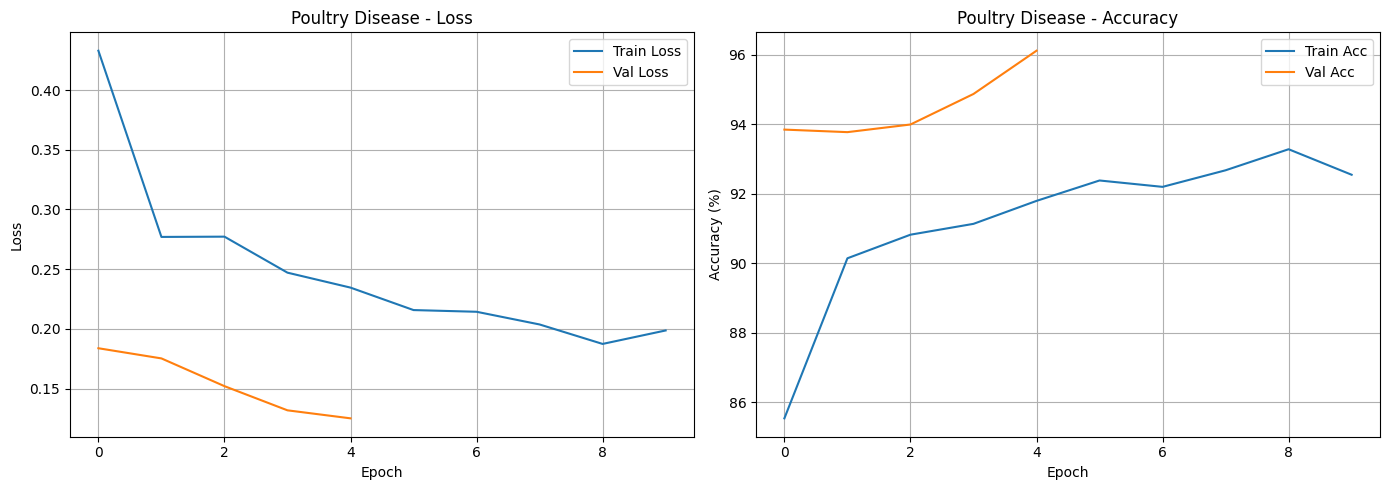

✅ Model saved to: /content/drive/MyDrive/models/poultry_model.pth
✅ Poultry Disease model trained! Best accuracy: 96.12%

############################################################
# TRAINING MULTI-CROP DISEASES MODEL
############################################################

🏗️  Training MULTI-CROP DISEASES Model
Data path: /content/data/disease_images/Multi-crop diseases
Save path: /content/drive/MyDrive/models/crops_model.pth
Epochs: 10, Batch Size: 64

📁 Preparing data...
Found classes: ['Rice Blast', 'thirps on  cotton', 'red cotton bug', 'Wheat black rust', 'Tungro', 'Yellow Rust Sugarcane', 'Sugarcane Healthy', 'Mosaic sugarcane', 'Brownspot', 'Wheat Brown leaf Rust', 'maize fall armyworm', 'maize ear rot', 'cotton mealy bug', 'Cotton Aphid', 'pink bollworm in cotton', 'Wheat powdery mildew', 'cotton whitefly', 'Healthy cotton', 'RedRust sugarcane', 'Wilt', 'Healthy Maize', 'Healthy Wheat', 'Flag Smut', 'Wheat Stem fly', 'Wheat mite', 'Becterial Blight in Rice', 'American B

Epoch 1/10 [Train]: 100%|██████████| 192/192 [02:18<00:00,  1.39it/s, loss=0.6685, acc=68.1%]



Epoch 1/10:
  Train Loss: 1.2536, Train Acc: 68.15%
  Val Loss: 0.0000, Val Acc: 0.00%


Epoch 2/10 [Val]: 100%|██████████| 49/49 [00:29<00:00,  1.68it/s]



Epoch 2/10:
  Train Loss: 0.6633, Train Acc: 80.63%
  Val Loss: 0.5235, Val Acc: 87.15%
  ✅ New best model! Val Acc: 87.15%


...


Epoch 8/10:
  Train Loss: 0.3902, Train Acc: 87.70%
  Val Loss: 0.3162, Val Acc: 91.63%
  ✅ New best model! Val Acc: 91.63%


Epoch 9/10 [Train]: 100%|██████████| 192/192 [02:14<00:00,  1.42it/s, loss=0.3075, acc=88.4%]



Epoch 9/10:
  Train Loss: 0.3754, Train Acc: 88.40%
  Val Loss: 0.3162, Val Acc: 91.63%


Epoch 10/10 [Val]: 100%|██████████| 49/49 [00:28<00:00,  1.75it/s]



Epoch 10/10:
  Train Loss: 0.3566, Train Acc: 88.74%
  Val Loss: 0.2872, Val Acc: 91.79%
  ✅ New best model! Val Acc: 91.79%

✅ Training complete! Best val accuracy: 91.79%


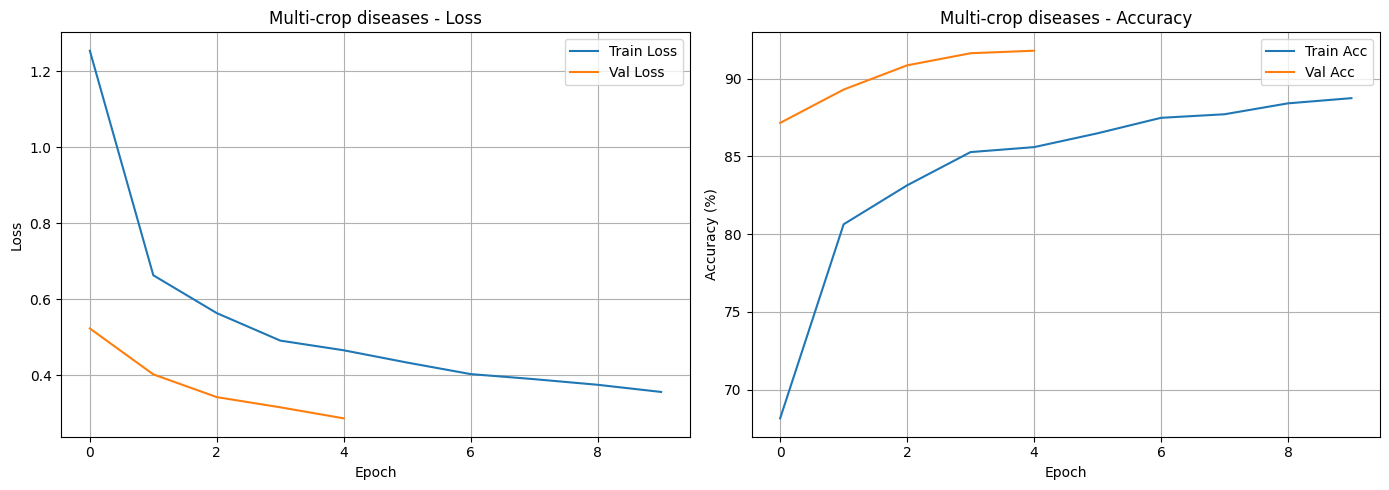

✅ Model saved to: /content/drive/MyDrive/models/crops_model.pth
✅ Multi-crop diseases model trained! Best accuracy: 91.79%

############################################################
# TRAINING LIVESTOCK DISEASES MODEL
############################################################

🏗️  Training LIVESTOCK DISEASES Model
Data path: /content/data/disease_images/Livestock Diseases
Save path: /content/drive/MyDrive/models/livestock_model.pth
Epochs: 10, Batch Size: 64

📁 Preparing data...
Found classes: ['Cow - Lumpy Skin', 'Pig - Viral FMD', 'Goat - Abscesses', 'Pig - Healthy', 'Pig - environmental sunburn', 'Pig - Bacterial Erysipelas', 'Cow - Healthy', 'Pig - Parasitic mange', 'Cow - Mastitis', 'Pig - Fungal ringworm', 'Cow - Dermatophilosis', 'Goat - Pox disease', 'Pig - Viral swinepox', 'Goat - Healthy', 'Pig - Fungal pityriasis rosea', 'Cow - Ringworm', 'Pig - Bacterial greasy pig disease', 'Cow - Foot and Mouth Disease', 'Cow - Pediculosis', 'Goat - Orf', 'Pig - Environmental Dermati

Epoch 1/10 [Train]: 100%|██████████| 147/147 [00:42<00:00,  3.43it/s, loss=1.7153, acc=40.1%]



Epoch 1/10:
  Train Loss: 1.9678, Train Acc: 40.13%
  Val Loss: 0.0000, Val Acc: 0.00%


Epoch 2/10 [Val]: 100%|██████████| 37/37 [00:04<00:00,  7.68it/s]



Epoch 2/10:
  Train Loss: 1.4739, Train Acc: 52.88%
  Val Loss: 1.2446, Val Acc: 60.13%
  ✅ New best model! Val Acc: 60.13%


...


Epoch 8/10:
  Train Loss: 1.1171, Train Acc: 63.12%
  Val Loss: 0.9714, Val Acc: 67.22%


Epoch 9/10 [Train]: 100%|██████████| 147/147 [00:39<00:00,  3.77it/s, loss=1.3211, acc=64.5%]



Epoch 9/10:
  Train Loss: 1.0843, Train Acc: 64.49%
  Val Loss: 0.9714, Val Acc: 67.22%


Epoch 10/10 [Val]: 100%|██████████| 37/37 [00:05<00:00,  7.25it/s]



Epoch 10/10:
  Train Loss: 1.0535, Train Acc: 64.88%
  Val Loss: 0.9149, Val Acc: 68.32%
  ✅ New best model! Val Acc: 68.32%

✅ Training complete! Best val accuracy: 68.32%


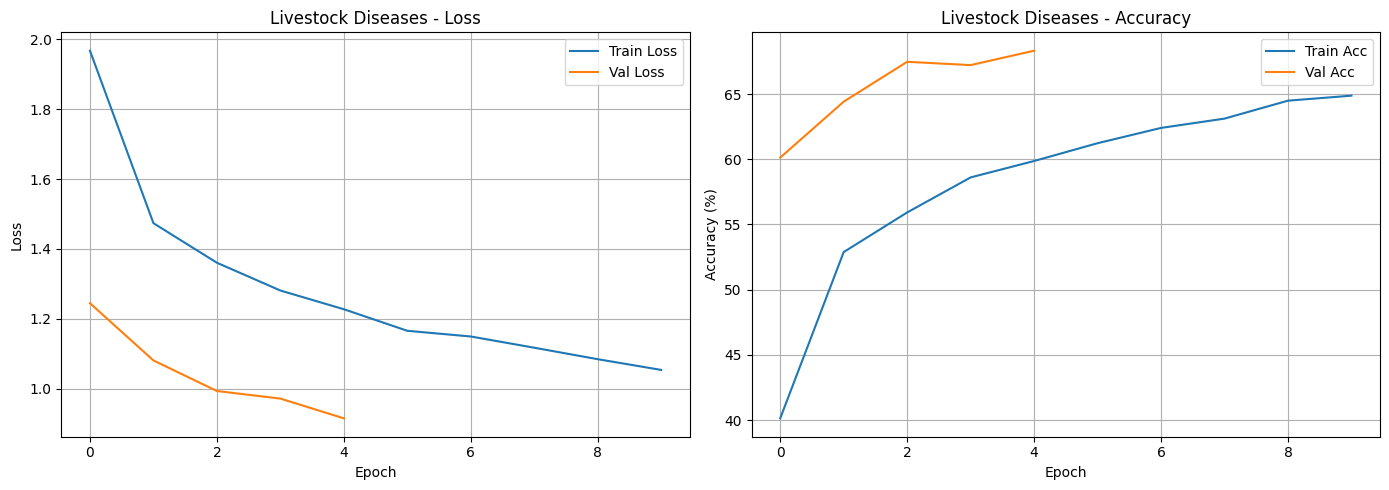

✅ Model saved to: /content/drive/MyDrive/models/livestock_model.pth
✅ Livestock Diseases model trained! Best accuracy: 68.32%

🎉 All models trained successfully!


In [9]:
# Define your folder structure
DATA_DIR = '/content/data/disease_images'

domains = [
    {'folder': 'Poultry Disease', 'short': 'poultry'},
    {'folder': 'Multi-crop diseases', 'short': 'crops'},
    {'folder': 'Livestock Diseases', 'short': 'livestock'}
]

# FAST TRAINING PARAMETERS
EPOCHS = 5              # Reduced from 20
BATCH_SIZE = 64          # Increased from 32

results = {}

for domain in domains:
    print(f"\n{'#'*60}")
    print(f"# TRAINING {domain['folder'].upper()} MODEL")
    print(f"{'#'*60}")

    trainer = FastModelTrainer(
        folder_name=domain['folder'],
        short_name=domain['short'],
        data_dir=DATA_DIR,
        num_epochs=EPOCHS,
        batch_size=BATCH_SIZE
    )

    try:
        history, best_acc = trainer.run()
        results[domain['short']] = {
            'history': history,
            'best_accuracy': best_acc,
            'class_names': trainer.class_names
        }
        print(f"✅ {domain['folder']} model trained! Best accuracy: {best_acc:.2f}%")
    except Exception as e:
        print(f"❌ Error training {domain['folder']}: {e}")

print("\n" + "="*60)
print("🎉 All models trained successfully!")
print("="*60)


📊 EVALUATING POULTRY DISEASE MODEL


Evaluating: 100%|██████████| 43/43 [00:03<00:00, 11.87it/s]



📊 Overall Metrics:
   Accuracy: 96.12%
   F1-Score (weighted): 0.9589
   Precision (weighted): 0.9608
   Recall (weighted): 0.9612

📊 Per-Class Metrics:
Class                Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
coccidiosis          0.9697       0.9881       0.9788       421.0     
healthy              0.9712       0.9806       0.9758       412.0     
new castle disease   0.9388       0.6053       0.7360       76.0      
salmonella           0.9469       0.9781       0.9622       456.0     


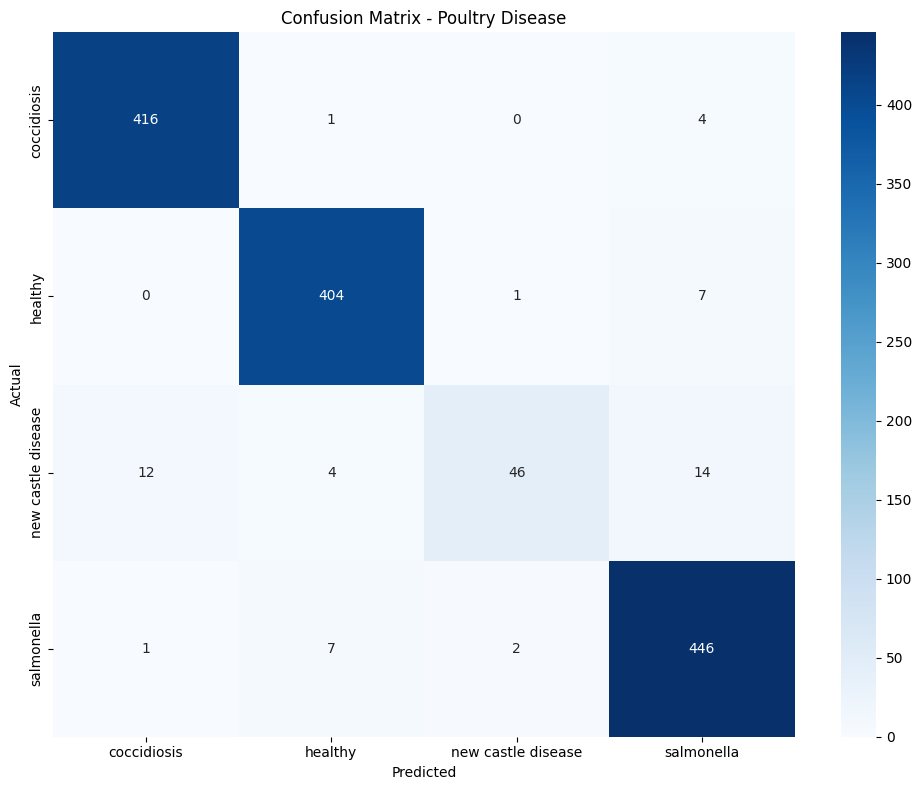


📊 EVALUATING MULTI-CROP DISEASES MODEL


Evaluating: 100%|██████████| 97/97 [00:28<00:00,  3.41it/s]



📊 Overall Metrics:
   Accuracy: 91.79%
   F1-Score (weighted): 0.9148
   Precision (weighted): 0.9147
   Recall (weighted): 0.9179

📊 Per-Class Metrics:
Class                Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
American Bollworm on Cotton 0.4615       0.5000       0.4800       12.0      
Anthracnose on Cotton 0.0000       0.0000       0.0000       6.0       
Army worm            0.6667       1.0000       0.8000       8.0       
Becterial Blight in Rice 0.9660       0.9874       0.9766       317.0     
Brownspot            0.9639       0.9756       0.9697       328.0     
Common_Rust          0.9768       0.9656       0.9712       262.0     
Cotton Aphid         0.5556       0.6250       0.5882       8.0       
Flag Smut            0.7955       0.9722       0.8750       36.0      
Gray_Leaf_Spot       0.9402       0.9565       0.9483       115.0     
Healthy Maize        0.9955       0.9485       0.9714

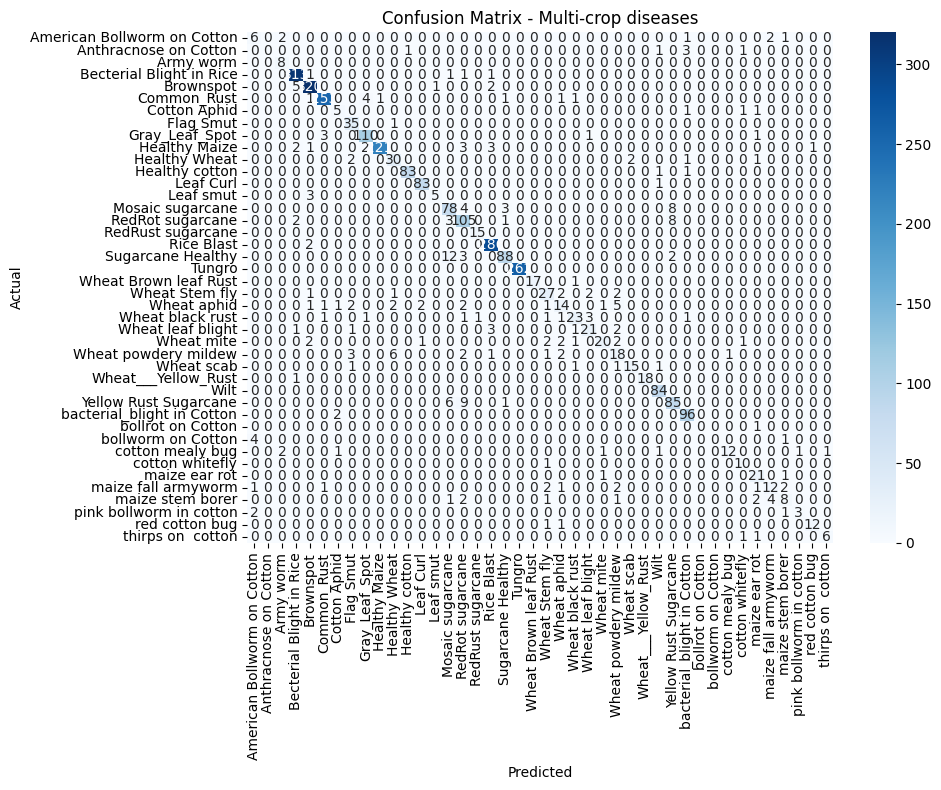


📊 EVALUATING LIVESTOCK DISEASES MODEL


Evaluating: 100%|██████████| 74/74 [00:04<00:00, 15.40it/s]



📊 Overall Metrics:
   Accuracy: 68.32%
   F1-Score (weighted): 0.6787
   Precision (weighted): 0.7029
   Recall (weighted): 0.6832

📊 Per-Class Metrics:
Class                Precision    Recall       F1-Score     Support   
----------------------------------------------------------------------
Cow - Dermatophilosis 0.6000       0.6067       0.6034       89.0      
Cow - Foot and Mouth Disease 0.8108       0.5217       0.6349       115.0     
Cow - Healthy        0.5411       0.8175       0.6512       137.0     
Cow - Lumpy Skin     0.5793       0.6667       0.6199       126.0     
Cow - Mastitis       0.8875       0.7889       0.8353       90.0      
Cow - Pediculosis    0.7812       0.2747       0.4065       91.0      
Cow - Ringworm       0.6168       0.6535       0.6346       101.0     
Goat - Abscesses     0.8690       0.8295       0.8488       88.0      
Goat - Healthy       0.7952       0.8462       0.8199       156.0     
Goat - Orf           0.8235       0.5773       0.6788   

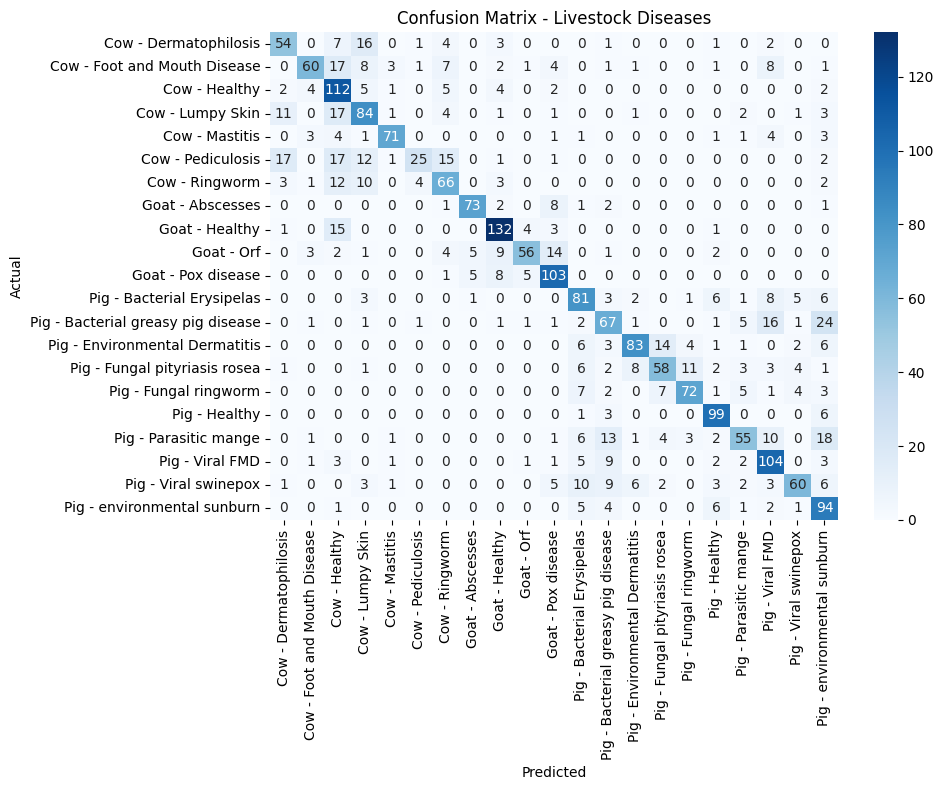


📊 EVALUATION SUMMARY

Domain               Accuracy     F1-Score     Precision    Recall      
----------------------------------------------------------------------
Poultry Disease      96.12       % 0.9589       0.9608       0.9612      
Multi-crop diseases  91.79       % 0.9148       0.9147       0.9179      
Livestock Diseases   68.32       % 0.6787       0.7029       0.6832      

✅ Evaluation complete!


In [10]:
# ============================================
# CELL 9: Model Evaluation
# ============================================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import datasets, transforms

def evaluate_model(domain_folder, short_name, data_dir, model_path):
    """
    Evaluate a trained model and return metrics.

    Parameters:
    - domain_folder: e.g., "Poultry Disease"
    - short_name: e.g., "poultry"
    - data_dir: path to data
    - model_path: path to saved model

    Returns:
    - Dictionary with metrics
    """

    print(f"\n{'='*60}")
    print(f"📊 EVALUATING {domain_folder.upper()} MODEL")
    print(f"{'='*60}")

    # Load model
    checkpoint = torch.load(model_path, map_location=device)
    class_names = checkpoint['class_names']
    num_classes = len(class_names)

    # Create model
    weights = models.EfficientNet_B0_Weights.DEFAULT
    model = models.efficientnet_b0(weights=weights)

    num_features = model.classifier[1].in_features
    model.classifier[1] = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )

    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()

    # Load validation data
    val_path = os.path.join(data_dir, domain_folder, 'val')

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    val_dataset = datasets.ImageFolder(val_path, transform=transform)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

    # Make predictions
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds) * 100
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')

    # Per-class metrics
    class_report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)

    print(f"\n📊 Overall Metrics:")
    print(f"   Accuracy: {accuracy:.2f}%")
    print(f"   F1-Score (weighted): {f1:.4f}")
    print(f"   Precision (weighted): {precision:.4f}")
    print(f"   Recall (weighted): {recall:.4f}")

    print(f"\n📊 Per-Class Metrics:")
    print(f"{'Class':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-" * 70)

    for class_name in class_names:
        if class_name in class_report:
            info = class_report[class_name]
            print(f"{class_name:<20} {info['precision']:<12.4f} {info['recall']:<12.4f} {info['f1-score']:<12.4f} {info['support']:<10}")

    # Plot confusion matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {domain_folder}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

    # Return metrics
    return {
        'accuracy': accuracy,
        'f1_weighted': f1,
        'precision_weighted': precision,
        'recall_weighted': recall,
        'class_report': class_report,
        'confusion_matrix': cm,
        'class_names': class_names,
        'predictions': all_preds,
        'labels': all_labels
    }


# ============================================
# Run Evaluation for All Models
# ============================================

# Define paths
DATA_DIR = '/content/data/disease_images'
MODEL_DIR = '/content/drive/MyDrive/models'

domains = [
    {'folder': 'Poultry Disease', 'short': 'poultry'},
    {'folder': 'Multi-crop diseases', 'short': 'crops'},
    {'folder': 'Livestock Diseases', 'short': 'livestock'}
]

evaluation_results = {}

for domain in domains:
    model_path = os.path.join(MODEL_DIR, f"{domain['short']}_model.pth")

    if os.path.exists(model_path):
        try:
            metrics = evaluate_model(
                domain_folder=domain['folder'],
                short_name=domain['short'],
                data_dir=DATA_DIR,
                model_path=model_path
            )
            evaluation_results[domain['short']] = metrics
        except Exception as e:
            print(f"❌ Error evaluating {domain['folder']}: {e}")
    else:
        print(f"⚠️ Model not found: {model_path}")

# ============================================
# Summary Table
# ============================================

print("\n" + "="*60)
print("📊 EVALUATION SUMMARY")
print("="*60)

print(f"\n{'Domain':<20} {'Accuracy':<12} {'F1-Score':<12} {'Precision':<12} {'Recall':<12}")
print("-" * 70)

for short_name, metrics in evaluation_results.items():
    # Get the full folder name
    folder_name = next((d['folder'] for d in domains if d['short'] == short_name), short_name)
    print(f"{folder_name:<20} {metrics['accuracy']:<12.2f}% {metrics['f1_weighted']:<12.4f} {metrics['precision_weighted']:<12.4f} {metrics['recall_weighted']:<12.4f}")

print("\n" + "="*60)
print("✅ Evaluation complete!")
print("="*60)

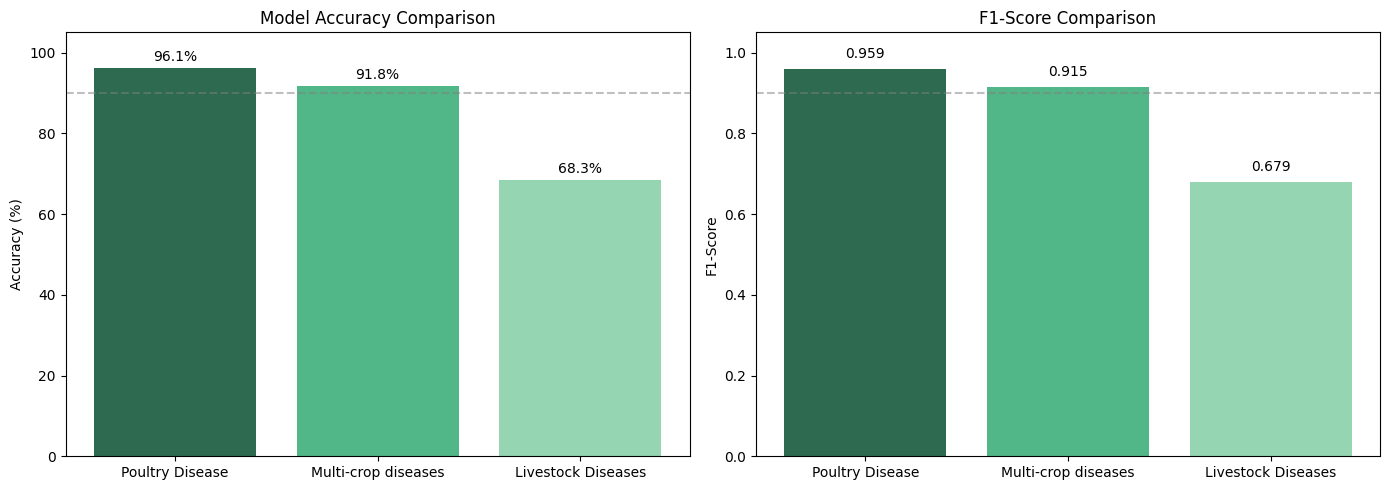

In [11]:
# ============================================
# CELL 10: Visualize Metrics Comparison
# ============================================

import matplotlib.pyplot as plt
import numpy as np

def plot_metrics_comparison(evaluation_results, domains):
    """Plot comparison of metrics across domains."""

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Extract metrics
    domain_names = []
    accuracies = []
    f1_scores = []

    for short_name, metrics in evaluation_results.items():
        folder_name = next((d['folder'] for d in domains if d['short'] == short_name), short_name)
        domain_names.append(folder_name)
        accuracies.append(metrics['accuracy'])
        f1_scores.append(metrics['f1_weighted'])

    # Plot Accuracy
    colors = ['#2D6A4F', '#52B788', '#95D5B2']
    bars1 = axes[0].bar(domain_names, accuracies, color=colors)
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title('Model Accuracy Comparison')
    axes[0].set_ylim(0, 105)
    axes[0].axhline(y=90, color='gray', linestyle='--', alpha=0.5)

    # Add value labels on bars
    for bar, acc in zip(bars1, accuracies):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{acc:.1f}%', ha='center', va='bottom', fontsize=10)

    # Plot F1-Score
    bars2 = axes[1].bar(domain_names, f1_scores, color=colors)
    axes[1].set_ylabel('F1-Score')
    axes[1].set_title('F1-Score Comparison')
    axes[1].set_ylim(0, 1.05)
    axes[1].axhline(y=0.9, color='gray', linestyle='--', alpha=0.5)

    # Add value labels on bars
    for bar, f1 in zip(bars2, f1_scores):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{f1:.3f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()


# Run the comparison
if evaluation_results:
    plot_metrics_comparison(evaluation_results, domains)
else:
    print("No evaluation results to plot.")

In [12]:
# ============================================
# CELL 11: Detailed Classification Report
# ============================================

import pandas as pd

def create_classification_table(evaluation_results, domains):
    """Create a detailed classification report table."""

    rows = []

    for short_name, metrics in evaluation_results.items():
        folder_name = next((d['folder'] for d in domains if d['short'] == short_name), short_name)

        for class_name, info in metrics['class_report'].items():
            if class_name not in ['accuracy', 'macro avg', 'weighted avg']:
                rows.append({
                    'Domain': folder_name,
                    'Class': class_name,
                    'Precision': info['precision'],
                    'Recall': info['recall'],
                    'F1-Score': info['f1-score'],
                    'Support': info['support']
                })

    df = pd.DataFrame(rows)

    # Pivot for better readability
    print("\n📊 Detailed Classification Report:")
    print("="*80)

    for domain in df['Domain'].unique():
        domain_df = df[df['Domain'] == domain]
        print(f"\n🔹 {domain.upper()}:")
        print(domain_df.to_string(index=False))
        print("-"*80)

    return df


if evaluation_results:
    df = create_classification_table(evaluation_results, domains)
else:
    print("No evaluation results to display.")


📊 Detailed Classification Report:

🔹 POULTRY DISEASE:
         Domain              Class  Precision   Recall  F1-Score  Support
Poultry Disease        coccidiosis   0.969697 0.988124  0.978824    421.0
Poultry Disease            healthy   0.971154 0.980583  0.975845    412.0
Poultry Disease new castle disease   0.938776 0.605263  0.736000     76.0
Poultry Disease         salmonella   0.946921 0.978070  0.962244    456.0
--------------------------------------------------------------------------------

🔹 MULTI-CROP DISEASES:
             Domain                       Class  Precision   Recall  F1-Score  Support
Multi-crop diseases American Bollworm on Cotton   0.461538 0.500000  0.480000     12.0
Multi-crop diseases       Anthracnose on Cotton   0.000000 0.000000  0.000000      6.0
Multi-crop diseases                   Army worm   0.666667 1.000000  0.800000      8.0
Multi-crop diseases    Becterial Blight in Rice   0.966049 0.987382  0.976599    317.0
Multi-crop diseases                

In [18]:
import os

livestock_path = '/content/data/disease_images/Livestock Diseases'

for class_name in os.listdir(livestock_path):
    if os.path.isdir(os.path.join(livestock_path, class_name)):
        num = len(os.listdir(os.path.join(livestock_path, class_name)))
        print(f"{class_name}: {num} images")

Cow - Lumpy Skin: 626 images
Pig - Viral FMD: 656 images
Goat - Abscesses: 437 images
Pig - Healthy: 542 images
Pig - environmental sunburn: 569 images
Pig - Bacterial Erysipelas: 583 images
Cow - Healthy: 682 images
Pig - Parasitic mange: 575 images
Cow - Mastitis: 450 images
Pig - Fungal ringworm: 508 images
Cow - Dermatophilosis: 445 images
Goat - Pox disease: 608 images
Pig - Viral swinepox: 555 images
Goat - Healthy: 780 images
Pig - Fungal pityriasis rosea: 496 images
Cow - Ringworm: 504 images
Pig - Bacterial greasy pig disease: 613 images
Cow - Foot and Mouth Disease: 575 images
Cow - Pediculosis: 451 images
Goat - Orf: 485 images
train: 21 images
val: 21 images
Pig - Environmental Dermatitis: 596 images



🏗️  Training LIVESTOCK DISEASES Model
Data path: /content/data/disease_images/Livestock Diseases
Save path: /content/drive/MyDrive/models/livestock_model.pth
Epochs: 25, Batch Size: 32

📁 Preparing data...
✅ Train/val split already exists.

📊 Data stats:
  Classes: ['Cow - Dermatophilosis', 'Cow - Foot and Mouth Disease', 'Cow - Healthy', 'Cow - Lumpy Skin', 'Cow - Mastitis', 'Cow - Pediculosis', 'Cow - Ringworm', 'Goat - Abscesses', 'Goat - Healthy', 'Goat - Orf', 'Goat - Pox disease', 'Pig - Bacterial Erysipelas', 'Pig - Bacterial greasy pig disease', 'Pig - Environmental Dermatitis', 'Pig - Fungal pityriasis rosea', 'Pig - Fungal ringworm', 'Pig - Healthy', 'Pig - Parasitic mange', 'Pig - Viral FMD', 'Pig - Viral swinepox', 'Pig - environmental sunburn']
  Train samples: 9381
  Val samples: 2355

🧠 Creating model with 21 classes...
✅ Model created on cuda

🚀 Starting fast training for 25 epochs...
   Mixed precision: Enabled


Epoch 1/25 [Train]: 100%|██████████| 294/294 [00:40<00:00,  7.23it/s, loss=2.7107, acc=40.7%]



Epoch 1/25:
  Train Loss: 1.9238, Train Acc: 40.69%
  Val Loss: 0.0000, Val Acc: 0.00%


Epoch 2/25 [Val]: 100%|██████████| 74/74 [00:05<00:00, 14.04it/s]



Epoch 2/25:
  Train Loss: 1.5160, Train Acc: 51.88%
  Val Loss: 1.2668, Val Acc: 58.64%
  ✅ New best model! Val Acc: 58.64%


...


Epoch 23/25:
  Train Loss: 0.9137, Train Acc: 70.08%
  Val Loss: 0.7417, Val Acc: 75.97%


Epoch 24/25 [Val]: 100%|██████████| 74/74 [00:04<00:00, 15.66it/s]



Epoch 24/25:
  Train Loss: 0.9066, Train Acc: 70.58%
  Val Loss: 0.7376, Val Acc: 76.69%
  ✅ New best model! Val Acc: 76.69%


Epoch 25/25 [Val]: 100%|██████████| 74/74 [00:04<00:00, 16.01it/s]



Epoch 25/25:
  Train Loss: 0.9109, Train Acc: 70.55%
  Val Loss: 0.7522, Val Acc: 76.18%

✅ Training complete! Best val accuracy: 76.69%


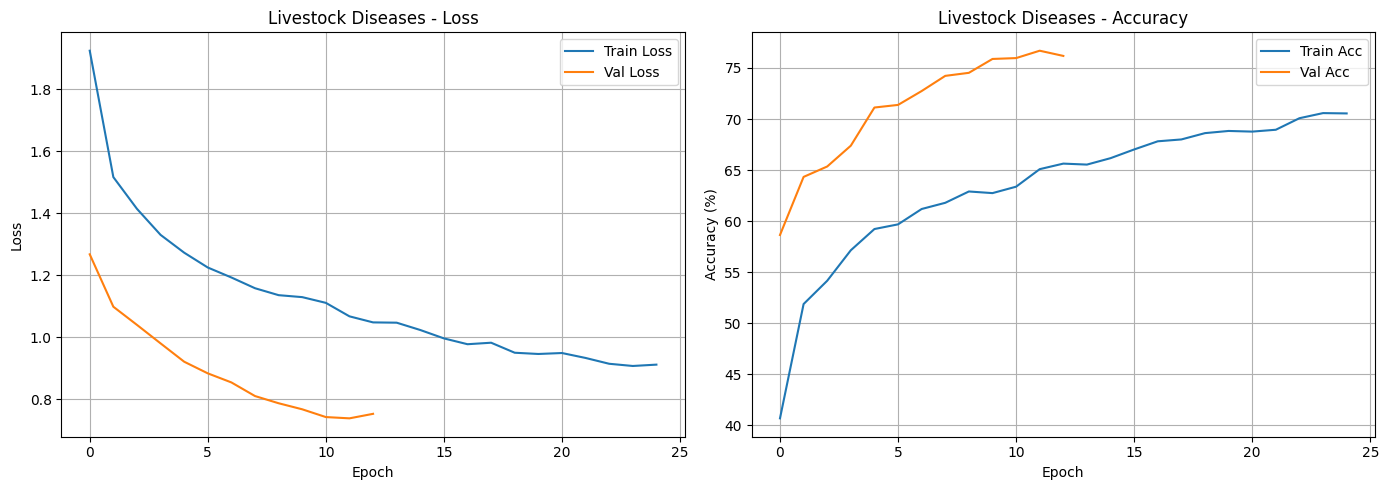

✅ Model saved to: /content/drive/MyDrive/models/livestock_model.pth


In [19]:
# Retrain only livestock with fixes
EPOCHS = 25
BATCH_SIZE = 32

# Use the improved trainer with class weights and augmentation
trainer = FastModelTrainer(
    folder_name='Livestock Diseases',
    short_name='livestock',
    data_dir=DATA_DIR,
    num_epochs=EPOCHS,
    batch_size=BATCH_SIZE
)
history, best_acc = trainer.run()

In [13]:
# ============================================
# CELL 12: Save Evaluation Results
# ============================================

import json
import pandas as pd

def save_evaluation_results(evaluation_results, save_path):
    """Save evaluation metrics to a JSON file."""

    # Convert to serializable format
    serializable_results = {}

    for domain, metrics in evaluation_results.items():
        serializable_results[domain] = {
            'accuracy': metrics['accuracy'],
            'f1_weighted': metrics['f1_weighted'],
            'precision_weighted': metrics['precision_weighted'],
            'recall_weighted': metrics['recall_weighted'],
            'class_names': metrics['class_names'],
            'class_report': {
                k: {
                    'precision': v['precision'],
                    'recall': v['recall'],
                    'f1-score': v['f1-score'],
                    'support': v['support']
                } for k, v in metrics['class_report'].items()
                if k not in ['accuracy', 'macro avg', 'weighted avg']
            }
        }

    # Save to Drive
    with open(save_path, 'w') as f:
        json.dump(serializable_results, f, indent=2)

    print(f"✅ Evaluation results saved to: {save_path}")

    # Also create a CSV version
    rows = []
    for domain, metrics in serializable_results.items():
        for class_name, info in metrics['class_report'].items():
            rows.append({
                'Domain': domain,
                'Class': class_name,
                'Precision': info['precision'],
                'Recall': info['recall'],
                'F1-Score': info['f1-score'],
                'Support': info['support']
            })

    df = pd.DataFrame(rows)
    csv_path = save_path.replace('.json', '.csv')
    df.to_csv(csv_path, index=False)
    print(f"✅ CSV saved to: {csv_path}")


# Save results
if evaluation_results:
    save_path = '/content/drive/MyDrive/models/evaluation_results.json'
    save_evaluation_results(evaluation_results, save_path)
else:
    print("No evaluation results to save.")

✅ Evaluation results saved to: /content/drive/MyDrive/models/evaluation_results.json
✅ CSV saved to: /content/drive/MyDrive/models/evaluation_results.csv


In [14]:
# Zip all models and download
!zip -r /content/models.zip /content/drive/MyDrive/models/
from google.colab import files
files.download('/content/models.zip')

print("="*60)
print("✅ Models downloaded!")
print("="*60)
print("\n📁 Your models are saved to:")
print("   /content/drive/MyDrive/models/")
print("\n📥 Download models.zip and extract to:")
print("   Agriculture-multi-agent/backend/models/")
print("\n   File structure should be:")
print("   models/")
print("   ├── crops_model.pth")
print("   ├── livestock_model.pth")
print("   └── poultry_model.pth")

  adding: content/drive/MyDrive/models/ (stored 0%)
  adding: content/drive/MyDrive/models/poultry_model.pth (deflated 8%)
  adding: content/drive/MyDrive/models/crops_model.pth (deflated 8%)
  adding: content/drive/MyDrive/models/livestock_model.pth (deflated 8%)
  adding: content/drive/MyDrive/models/evaluation_results.json (deflated 80%)
  adding: content/drive/MyDrive/models/evaluation_results.csv (deflated 62%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Models downloaded!

📁 Your models are saved to:
   /content/drive/MyDrive/models/

📥 Download models.zip and extract to:
   Agriculture-multi-agent/backend/models/

   File structure should be:
   models/
   ├── crops_model.pth
   ├── livestock_model.pth
   └── poultry_model.pth
